# Normalizacija podataka
Cilj normalizacije je transformacija atributa da budu na sličnim skalama. 

Četiri najčešće korišćene tehnike normalizacije:
* Skaliranje na određeni raspon
* Odsecanje vrednosti
* Logaritamsko skaliranje
* Z-score normalizacija (standardizacija)

Prikaz ovih tehnika će biti nad skupom podataka <a href="https://archive.ics.uci.edu/ml/datasets/Automobile">1985 Ward's Automotive Yearbook</a> koji se nalazi na UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Ucitavanje skupa
data = pd.read_csv('datasets/Automobile_data.csv')
data.shape

(205, 26)

Fokusiraćemo se na atribut _price_. Za domaći analizirati ostale atribute.

U opisu skupa podataka je naznačeno da su nedostajuće vrednosti prikazane kao _?_. Ove vrednosti su uticale i na tip atributa.

In [3]:
data['price'].describe()

count     205
unique    187
top         ?
freq        4
Name: price, dtype: object

Ukoliko na standardan način proverimo da li postoje nedostajuće vrednosti dobijamo da ih nema. (jer nisu NaN nego ?)

In [4]:
# Imamo nedostajuće vrednosti, vidimo i da nije numericki tip
data['price'].isna().any()

False

Potrebno je da zamenimo ? sa NaN i da izvrsimo konverziju tipa atributa _price_.

In [5]:
data.replace("?", np.nan, inplace=True)
data['price'] = data['price'].astype('float64')

In [6]:
data['price'].isna().sum() # Sada nam se prikazuju nedostajuce vrednosti

4

In [7]:
# Pošto ćemo imati više sličnih plotova
def plot_hist(X, title):
    plt.title(title)
    X.hist(bins=45)
    plt.xlabel('cena')

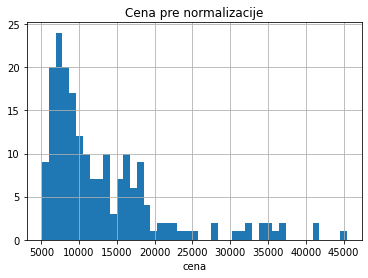

In [8]:
# Plotovati histogram pre normalizacije
plot_hist(data['price'], "Cena pre normalizacije")

## Min-max skaliranje

Transformisemo vrednosti atributa iz prirodnog raspona [min, max], na raspon [0, 1].

Formula:

  $x^{'} = \frac{x-min}{max-min}$


Pogodan za korišćenje:

* Ako približno znamo gornje i donje ograničenje.
* Ako podaci sadrže malo (ili ne sadrže) autlajere.
* Ako su podaci približno uniformno distribuirani na rasponu.

Primer kada bi ovaj tip normalizacije bio dobar: godine.
Primer kada bi ovaj tip normalizacije bio loš: godišnja primanja.


In [9]:
def minmax(X):
      return (X - min(X))/(max(X) - min(X))

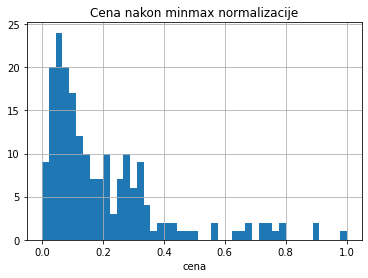

In [10]:
price_minmax = minmax(data['price'])
plot_hist(price_minmax, "Cena nakon minmax normalizacije")

## Odsecanje vrednosti

Ako podaci imaju ekstremne autlajere možemo koristiti odsecanje. Tada se sve vrednosti manje od minimalne zadate slikaju u min. Analogno važi za max.

Formula:

$clipping(x, min, max) = \left\{ 
  \begin{array}{ c l }
    min & x < min \\
    max & x > max \\
    x & inace
  \end{array}
\right.$

Može se primeniti pre i posle drugih vrsta normalizacije.

In [11]:
def clipping(X, x_min, x_max):
    X.where(X > x_min, x_min, inplace=True)
    X.where(X < x_max, x_max, inplace=True)
    return X

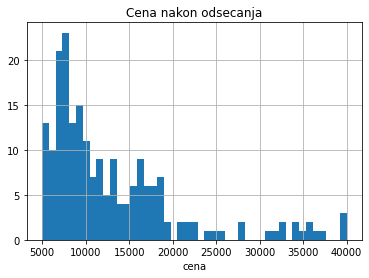

In [12]:
price_clip = clipping(data['price'], 5000, 40000)
plot_hist(price_clip, "Cena nakon odsecanja")

## Logaritamsko skaliranje

$x^{'} = log(x)$

Logaritamsko skaliranje je korisno ukoliko ukoliko imamo raspodelu verovatnoće stepenog zakona (Paretova raspodela).

Intuitivno: ako imamo malo tacaka sa velikim vrednostima i dosta tacaka sa malim vrednostima. Npr: raspodela bogatstva u društvu, filmske recenzije.

Iz tog razloga koristimo logaritam, da smanjimo razliku između vrednosti.


In [13]:
def log(X):
    return np.log(X)

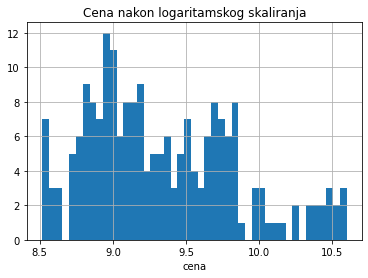

In [14]:
price_log = log(data['price'])
plot_hist(price_log, "Cena nakon logaritamskog skaliranja")

## Z-score normalizacija (standardizacija)

Z-score kvantifikuje koliko standardinh devijacija je vrednost udaljena od srednje vrednosti. On pokazuje gde se vrednost nalazi u distribuciji, pri čemu z-skor od 0 jednak je srednjoj vrednosti, pozitivne vrednosti iznad nje, a negativne vrednosti ispod nje.

Koristimo kada želimo da osiguramo da je mean = 0  i std = 1.
Korisno ako imamo outlajere, ali ne ekstremne da nam treba odsecanje

Formula:
  
  $x^{'} = \frac{x- μ}{σ}$

In [15]:
def z_score(X):
    return (X - X.mean()) / X.std()

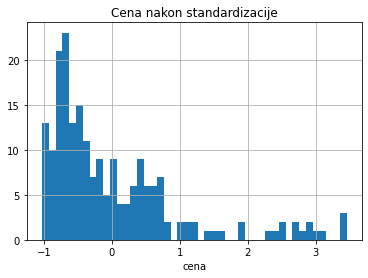

In [16]:
price_zscore = z_score(data['price'])
plot_hist(price_zscore, "Cena nakon standardizacije")

### Rezime:

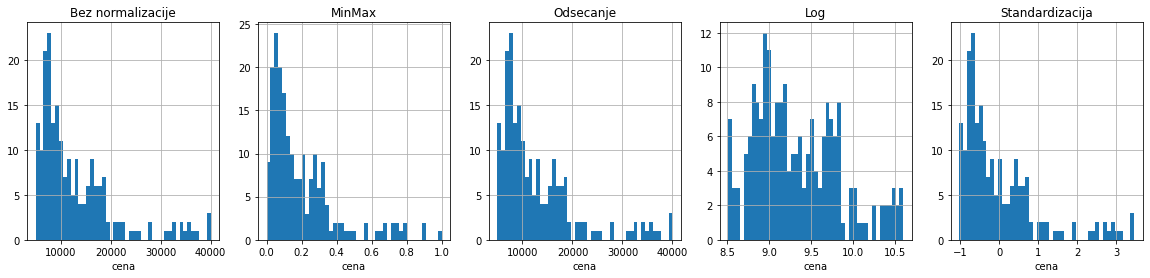

In [17]:
plot_values = [data['price'], price_minmax, price_clip, price_log, price_zscore]
plot_titles = ["Bez normalizacije", "MinMax", "Odsecanje", "Log", "Standardizacija"]

plt.figure(figsize=(20, 4))

for i in range(len(plot_values)):
    plt.subplot(1, 5, i+1)
    plot_hist(plot_values[i], plot_titles[i])